In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

In [3]:
from src.models.lstm import LSTMNextWordPredictor

In [4]:
import pickle
with open("../data/processed/vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

with open("../data/processed/X.pkl", "rb") as f:
    X = pickle.load(f)

with open("../data/processed/y.pkl", "rb") as f:
    y = pickle.load(f)

In [5]:
from src.data.dataset import NextWordDataset

In [6]:
dataset = NextWordDataset(X, y)

In [7]:
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

In [8]:
vocab_size = len(vocab.word_to_idx)

print(vocab_size)

39275


In [9]:
model = LSTMNextWordPredictor(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256
)

print(model)

LSTMNextWordPredictor(
  (embedding): Embedding(39275, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=39275, bias=True)
)


In [10]:
sample_x, sample_y = next(iter(train_loader))

output = model(sample_x)

print(output.shape)

torch.Size([64, 39275])


In [11]:
from src.training.trainer import Trainer

In [12]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [13]:
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    learning_rate=0.001,
    device=device
)

In [14]:
loss = trainer.train_one_epoch()

print("Loss:", loss)

Training: 100%|██████████| 3125/3125 [02:57<00:00, 17.56it/s, loss=6.49]

Loss: 6.586594548339844


In [15]:
num_epochs = 20

losses = []

for epoch in range(num_epochs):

    loss = trainer.train_one_epoch()

    losses.append(loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {loss:.4f}"
    )

Training: 100%|██████████| 3125/3125 [03:56<00:00, 13.19it/s, loss=5.15]


Epoch [1/20] Loss: 5.7197


Training: 100%|██████████| 3125/3125 [03:08<00:00, 16.59it/s, loss=5.01]


Epoch [2/20] Loss: 5.2099


Training: 100%|██████████| 3125/3125 [03:14<00:00, 16.09it/s, loss=4.05]


...

Epoch [18/20] Loss: 1.6520


Training: 100%|██████████| 3125/3125 [03:15<00:00, 15.96it/s, loss=2.27] 


Epoch [19/20] Loss: 1.5840


Training: 100%|██████████| 3125/3125 [03:14<00:00, 16.05it/s, loss=1.8]  


Epoch [20/20] Loss: 1.5256


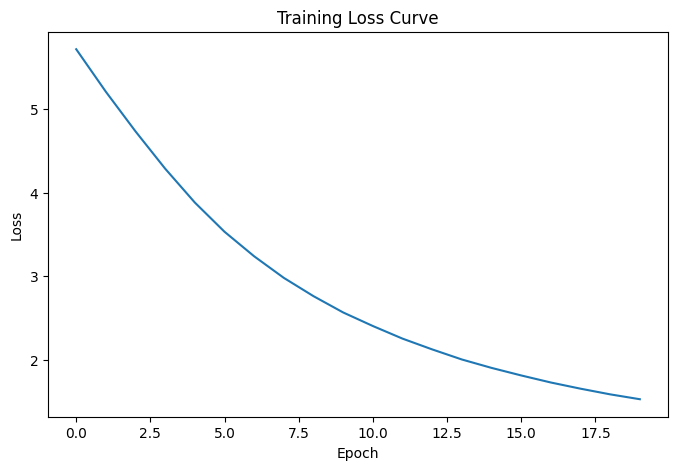

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.show()

In [17]:
torch.save(
    model.state_dict(),
    "../models/lstm_model.pth"
)

In [18]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab_size": len(vocab.word_to_idx),
    "word_to_idx": vocab.word_to_idx,
    "idx_to_word": vocab.idx_to_word,
    "embedding_dim": 128,
    "hidden_dim": 256,
    "num_layers": 2
}

torch.save(
    checkpoint,
    "../models/lstm_checkpoint.pth"
)

print("Checkpoint Saved")

Checkpoint Saved
